# Experiment Hub: Program Synthesis for Efficient ML

Central notebook for running all experiments, collecting data, and plotting results.

**Sections:**
1. Synthesis + Accuracy Pipeline
2. Hyperparameter Sweep
3. Grammar Selection Study
4. Ablation Study (CVC5 vs FloPoCo, Constraint Relaxation, Bitvector Sweep)
5. Cross-cutting Summary

In [1]:
import json
import os

# Ensure iverilog/vvp are on PATH (conda pkg cache on supervisor server)
os.environ["PATH"] = "/home/josephluke/.local/bin:/home/josephluke/.conda/pkgs/iverilog-11.0-hd56c0c9_0/bin:" + os.environ.get("PATH", "")
import re
import shutil
import subprocess
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while root != root.parent:
        if (root / "src" / "synthesis_driver.py").exists() and (root / "accuracy_tests" / "Makefile").exists():
            return root
        root = root.parent
    raise RuntimeError("Could not locate repo root")


ROOT = find_repo_root()
ACC_DIR = ROOT / "accuracy_tests"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.run_vitis_hls import parse_reports


# ────────────── Shared helpers ──────────────

def tail(text: str, lines: int = 200) -> str:
    parts = (text or "").splitlines()
    return "\n".join(parts[-lines:])


def extract_metrics(text: str) -> dict:
    """Parse cocotb test output for accuracy metrics (MXINT8 and FP32 formats)."""
    metrics: dict = {}
    for raw in (text or "").splitlines():
        line = raw.strip()
        # MXINT8 format: "Ran N test cases (skipped M)"
        m_ran = re.search(r"Ran\s+\d+\s+(?:test\s+)?cases?\s+\(skipped\s+\d+\)", line)
        if m_ran:
            metrics["ran"] = m_ran.group(0)
        if "Percent Within" in line:
            metrics.setdefault("percent_within", []).append(line)
        if "Max Absolute Error:" in line:
            metrics.setdefault("max_abs", []).append(line)
        if "Average Absolute Error:" in line:
            metrics.setdefault("avg_abs", []).append(line)
        if "99th Percentile" in line:
            metrics.setdefault("p99", []).append(line)
        if "95th Percentile" in line:
            metrics.setdefault("p95", []).append(line)
        # FP32 inline format: "[IN-DIST ...] ... Exact match: X%. Within Y% relative error: Z%"
        # or untagged: "Ran N cases (skipped M). Exact match: X%. Within Y% relative error: Z%"
        if "[IN-DIST" in line or "[GENERALISATION" in line:
            metrics.setdefault("fp32_inline", []).append(line)
            m_ran2 = re.search(r"Ran\s+\d+\s+cases\s+\(skipped\s+\d+\)", line)
            if m_ran2:
                metrics["ran"] = m_ran2.group(0)
        elif "Exact match:" in line and "Within" in line and "relative error" in line:
            metrics.setdefault("fp32_inline", []).append("[IN-DIST] " + line)
            m_ran2 = re.search(r"Ran\s+\d+\s+cases\s+\(skipped\s+\d+\)", line)
            if m_ran2:
                metrics["ran"] = m_ran2.group(0)
    return metrics


def parse_accuracy_rc_from_driver(text: str):
    if "[SUCCESS] Accuracy run completed successfully." in text:
        return 0
    m = re.search(r"Accuracy run failed with return code\s+(\d+)", text)
    return int(m.group(1)) if m else None


def _parse_ran(line):
    m = re.search(r"Ran\s+(\d+)\s+(?:test\s+)?cases?\s+\(skipped\s+(\d+)\)", line or "")
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)


def _parse_value_after_colon(line):
    m = re.search(r":\s*(-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", line or "")
    return float(m.group(1)) if m else np.nan


def _parse_percent_after_colon(line):
    m = re.search(r":\s*([0-9]+(?:\.[0-9]+)?)\s*%", line or "")
    return float(m.group(1)) if m else np.nan


def tol_tag(value: float) -> str:
    return str(value).replace(".", "p")


def parse_mode_tol(tag: str) -> tuple:
    m = re.match(r"^mode_(.+)__rel_([0-9p]+)$", tag)
    if not m:
        return ("unknown", float("nan"))
    return (m.group(1), float(m.group(2).replace("p", ".")))


print(f"Repo root: {ROOT}")
print("Setup complete.")

Repo root: /home/josephluke/Program-Synthesis-for-Efficient-ML
Setup complete.


# 1. Synthesis + Accuracy Pipeline

Runs SMT synthesis, hardware synthesis (Vitis HLS + Vivado), and cocotb accuracy tests for all targets.
Covers `FP32` and `MXINT8` addition/multiplication — both `subcomponent` and `combined` variants, plus FloPoCo baselines.

In [2]:
# ──────── Knobs ────────
RUN_IMPL = True
RUN_ACCURACY = True
ENABLE_DIRECTED_IO = True
NUM_ITERATIONS = 30
SOLVER_TIMEOUT_SECONDS = 120
SHOW_FULL_LOG = False
TAIL_LINES = 200

# ──────── Jobs ────────
SYNTH_JOBS = [
    {"name": "mxint8_add_subcomponents", "target": "mxint8_add", "component": "full_sum",
     "op": "Addition", "dtype": "MXINT8", "variant": "Subcomponents",
     "soln": "solution_mxint8addition_full_sum", "top": "add_full_sum", "base": "HLS"},
    {"name": "mxint8_add_combined", "target": "mxint8_add", "component": "full_sum_combined",
     "op": "Addition", "dtype": "MXINT8", "variant": "Combined",
     "soln": "solution_mxint8addition_full_sum_combined", "top": "add_full_sum", "base": "HLS"},
    {"name": "mxint8_mul_subcomponents", "target": "mxint8_mul", "component": "full_product",
     "op": "Multiplication", "dtype": "MXINT8", "variant": "Subcomponents",
     "soln": "solution_mxint8multiplication_full_product", "top": "mult_mxint_full_product", "base": "HLS"},
    {"name": "mxint8_mul_combined", "target": "mxint8_mul", "component": "full_product_combined",
     "op": "Multiplication", "dtype": "MXINT8", "variant": "Combined",
     "soln": "solution_mxint8multiplication_full_product_combined", "top": "mult_mxint_full_product", "base": "HLS"},
    {"name": "fp32_add_subcomponents", "target": "fp32_add", "component": "full_sum",
     "op": "Addition", "dtype": "FP32", "variant": "Subcomponents",
     "soln": "solution_fp32addition_full_sum", "top": "fp32_sum", "base": "HLS"},
    {"name": "fp32_add_combined", "target": "fp32_add", "component": "full_sum_combined",
     "op": "Addition", "dtype": "FP32", "variant": "Combined",
     "soln": "solution_fp32addition_full_sum_combined", "top": "fp32_sum", "base": "HLS"},
    {"name": "fp32_mul_subcomponents", "target": "fp32_mul", "component": "full_product",
     "op": "Multiplication", "dtype": "FP32", "variant": "Subcomponents",
     "soln": "solution_fp32multiplication_full_product", "top": "fp32_full_mul", "base": "HLS"},
    {"name": "fp32_mul_combined", "target": "fp32_mul", "component": "full_product_combined",
     "op": "Multiplication", "dtype": "FP32", "variant": "Combined",
     "soln": "solution_fp32multiplication_full_product_combined", "top": "fp32_full_mul", "base": "HLS"},
]

print(f"Running unified synthesis+accuracy pipeline for {len(SYNTH_JOBS)} synthesis jobs")
results = []

for job in SYNTH_JOBS:
    print(f"\n=== Pipeline run: {job['name']} ===")
    env = os.environ.copy()
    env.update({
        "SYNTH_TARGET": job["target"], "SYNTH_COMPONENT": job["component"],
        "SYNTH_RUN_IMPL": "1" if RUN_IMPL else "0",
        "SYNTH_RUN_ACCURACY": "1" if RUN_ACCURACY else "0",
        "SYNTH_ENABLE_DIRECTED_IO": "1" if ENABLE_DIRECTED_IO else "0",
        "SYNTH_NUM_ITERATIONS": str(NUM_ITERATIONS),
        "SYNTH_SOLVER_TIMEOUT": str(SOLVER_TIMEOUT_SECONDS),
        "SYNTH_FP32_AUTO_RELAX_OUTPUT_MATCH": "0",
    })
    proc = subprocess.run([sys.executable, "-m", "src.synthesis_driver"],
                          cwd=ROOT, env=env, text=True, capture_output=True)
    stdout, stderr = proc.stdout or "", proc.stderr or ""
    if SHOW_FULL_LOG:
        print(stdout)
    else:
        print(tail(stdout, TAIL_LINES))
    if stderr:
        print("\n[stderr tail]\n" + tail(stderr, TAIL_LINES))

    metrics = extract_metrics(stdout)
    if not metrics and stderr:
        metrics = extract_metrics(stderr)
    acc_rc = parse_accuracy_rc_from_driver(stdout) if RUN_ACCURACY else None
    results.append({
        "name": job["name"], "op": job["op"], "dtype": job["dtype"],
        "variant": job["variant"], "soln": job["soln"], "top": job["top"],
        "base": job["base"], "pipeline_returncode": proc.returncode,
        "returncode": acc_rc, "metrics": metrics,
    })

print("\n=== Run Summary ===")
for r in results:
    p_status = "PASS" if (pd.isna(r.get("pipeline_returncode")) or r["pipeline_returncode"] == 0) else "FAIL"
    a_status = "SKIP" if r["returncode"] is None else ("PASS" if r["returncode"] == 0 else "FAIL")
    print(f"{r['name']}: pipeline={p_status}, accuracy={a_status}")

# Cache results
results_cache = ROOT / "results" / "notebooks" / "latest_unified_results.json"
results_cache.parent.mkdir(parents=True, exist_ok=True)
try:
    results_cache.write_text(json.dumps(results, indent=2, default=str))
    print(f"Saved run results cache: {results_cache}")
except Exception as e:
    print(f"[WARN] Could not save cache: {e}")

Running unified synthesis+accuracy pipeline for 8 synthesis jobs

=== Pipeline run: mxint8_add_subcomponents ===
--- alignment ---
(define-fun select_exponent ((e1 (_ BitVec 4)) (e2 (_ BitVec 4))) (_ BitVec 4) (ite (bvsge e1 e2) e1 e2))
(define-fun align_mantissas ((m1 (_ BitVec 4)) (e1 (_ BitVec 4)) (m2 (_ BitVec 4)) (e2 (_ BitVec 4))) (_ BitVec 8) (let ((_let_1 (bvsge e1 e2))) (let ((_let_2 (ite _let_1 m1 m2))) (let ((_let_3 (bvsub ((_ sign_extend 1) (ite (bvsgt e1 e2) e1 e2)) ((_ sign_extend 1) (ite _let_1 e2 e1))))) (let ((_let_4 ((_ extract 3 0) _let_3))) (let ((_let_5 (ite _let_1 m2 m1))) (let ((_let_6 ((_ sign_extend 1) _let_5))) (concat (ite _let_1 _let_2 ((_ extract 3 0) (bvashr _let_6 _let_3))) (ite _let_1 (ite (bvsge _let_3 #b00100) #b0000 ((_ extract 3 0) (bvashr (bvadd _let_6 ((_ sign_extend 1) (ite (bvslt _let_5 #b0000) (bvneg (ite (= _let_4 #b0001) #b0001 (ite (= _let_4 #b0010) #b0010 (ite (= _let_4 #b0011) #b0100 #b0000)))) _let_4))) _let_3))) _let_2)))))))))

--- raw_s

KeyboardInterrupt: 

In [7]:
# ──────── FloPoCo Accuracy (GHDL required) ────────
# Run this cell to test FloPoCo baselines. Requires GHDL on PATH.
# Results are appended to the `results` list used by the next cell.

FLOPOCO_ACCURACY_JOBS = [
    {"name": "fp32_add_flopoco", "op": "Addition", "dtype": "FP32", "variant": "Flopoco",
     "soln": "solution_fp32addition_flopoco", "top": "fp32_sum_flopoco",
     "module": "tests.addition.test_fp32_adder", "variant_env": "FP32_ADD_VARIANT",
     "variant_value": "flopoco", "base": "FLOPOCO"},
    {"name": "fp32_mul_flopoco", "op": "Multiplication", "dtype": "FP32", "variant": "Flopoco",
     "soln": "solution_fp32multiplication_flopoco", "top": "fp32_full_mul_flopoco",
     "module": "tests.multiplication.test_fp32_multiplier", "variant_env": "FP32_MUL_VARIANT",
     "variant_value": "flopoco", "base": "FLOPOCO"},
]

if "results" not in globals():
    results = []

# Remove any existing FloPoCo entries so re-runs don't duplicate
results = [r for r in results if r.get("variant") != "Flopoco"]

flopoco_log_lines = []
for job in FLOPOCO_ACCURACY_JOBS:
    print(f"\n=== FloPoCo: {job['name']} ===")
    rtl_dir = ROOT / "results" / job["base"] / job["soln"] / "verilog_out"
    if not rtl_dir.exists():
        print(f"Skipping {job['name']} (missing RTL dir: {rtl_dir})")
        results.append({"name": job["name"], "op": job["op"], "dtype": job["dtype"],
                        "variant": job["variant"], "soln": job["soln"], "top": job["top"],
                        "base": job["base"], "pipeline_returncode": np.nan,
                        "returncode": None, "metrics": {}})
        continue
    env = os.environ.copy()
    env.update({
        "HLS_BASE": str(ROOT / "results" / job["base"]),
        "HLS_SOLN": job["soln"], "TOPLEVEL": job["top"],
        "TOPLEVEL_LANG": "vhdl", "SIM": "ghdl",
        "GHDL_ARGS": "-fsynopsys -fexplicit",
        "MODULE": job["module"], job["variant_env"]: job["variant_value"],
    })
    proc = subprocess.run(["make", "-f", "Makefile", "results.xml"],
                          cwd=ACC_DIR, env=env, text=True, capture_output=True)
    print(tail(proc.stdout, 200))
    if proc.stderr:
        print("\n[stderr tail]\n" + tail(proc.stderr, 200))
    metrics = extract_metrics(proc.stdout)
    if not metrics and proc.stderr:
        metrics = extract_metrics(proc.stderr)
    results.append({"name": job["name"], "op": job["op"], "dtype": job["dtype"],
                    "variant": job["variant"], "soln": job["soln"], "top": job["top"],
                    "base": job["base"], "pipeline_returncode": np.nan,
                    "returncode": proc.returncode, "metrics": metrics})

flopoco_results = [r for r in results if r.get("variant") == "Flopoco"]
for r in flopoco_results:
    a_status = "SKIP" if r["returncode"] is None else ("PASS" if r["returncode"] == 0 else "FAIL")
    print(f"{r['name']}: accuracy={a_status}")



=== FloPoCo: fp32_add_flopoco ===
\
/home/josephluke/.local/bin/ghdl -i -fsynopsys -fexplicit   --workdir=/home/josephluke/Program-Synthesis-for-Efficient-ML/accuracy_tests/sim_build/fp32_sum_flopoco_solution_fp32addition_flopoco --work=work /home/josephluke/Program-Synthesis-for-Efficient-ML/results/FLOPOCO/solution_fp32addition_flopoco/verilog_out/fp32_add_flopoco.vhd /home/josephluke/Program-Synthesis-for-Efficient-ML/results/FLOPOCO/solution_fp32addition_flopoco/verilog_out/fp32_sum_flopoco.vhd  && \
/home/josephluke/.local/bin/ghdl -m -fsynopsys -fexplicit   --workdir=/home/josephluke/Program-Synthesis-for-Efficient-ML/accuracy_tests/sim_build/fp32_sum_flopoco_solution_fp32addition_flopoco -P/home/josephluke/Program-Synthesis-for-Efficient-ML/accuracy_tests/sim_build/fp32_sum_flopoco_solution_fp32addition_flopoco --work=work fp32_sum_flopoco 
rm -f results.xml
COCOTB_TEST_MODULES=tests.addition.test_fp32_adder COCOTB_TESTCASE= COCOTB_TEST_FILTER= COCOTB_TOPLEVEL=fp32_sum_flopoco 

Loaded from cache: /home/josephluke/Program-Synthesis-for-Efficient-ML/results/notebooks/latest_unified_results.json
Merged 2 FloPoCo results from Cell 4
Unified hardware + accuracy summary


,op,dtype,variant,status,tested,LUTs,FFs,DSPs,BRAMs,Fmax_MHz,within5pct,fp32_indist_exact,fp32_indist_within_rel,fp32_gen_exact,fp32_gen_within_rel,Cycles
0,Addition,FP32,Combined,PASS,49998,41,0,0,0,238.095,3.74,0.00,3.74,0.00,0.24,0
1,Addition,FP32,Flopoco,PASS,49998,431,394,0,0,171.615,100.00,100.00,100.00,100.00,100.00,7
2,Addition,FP32,Subcomponents,PASS,49998,458,0,0,0,239.177,100.00,65.56,100.00,90.74,100.00,0
3,Addition,MXINT8,Combined,PASS,100000,55,0,0,0,45.773,40.54,NaN,NaN,NaN,NaN,0
4,Addition,MXINT8,Subcomponents,PASS,100000,64,0,0,0,34.050,48.48,NaN,NaN,NaN,NaN,0
5,Multiplication,FP32,Combined,PASS,82957,21,0,2,0,87.283,90.46,45.16,90.46,NaN,NaN,0
6,Multiplication,FP32,Flopoco,PASS,82957,357,116,1,0,201.329,100.00,100.00,100.00,NaN,NaN,4
7,Multiplication,FP32,Subcomponents,PASS,82957,32,0,2,0,74.355,90.46,90.46,90.46,NaN,NaN,0
8,Multiplication,MXINT8,Combined,PASS,100000,15,0,0,0,301.568,64.10,NaN,NaN,NaN,NaN,0
9,Multiplication,MXINT8,Subcomponents,PASS,100000,21,0,0,0,199.442,35.47,NaN,NaN,NaN,NaN,0


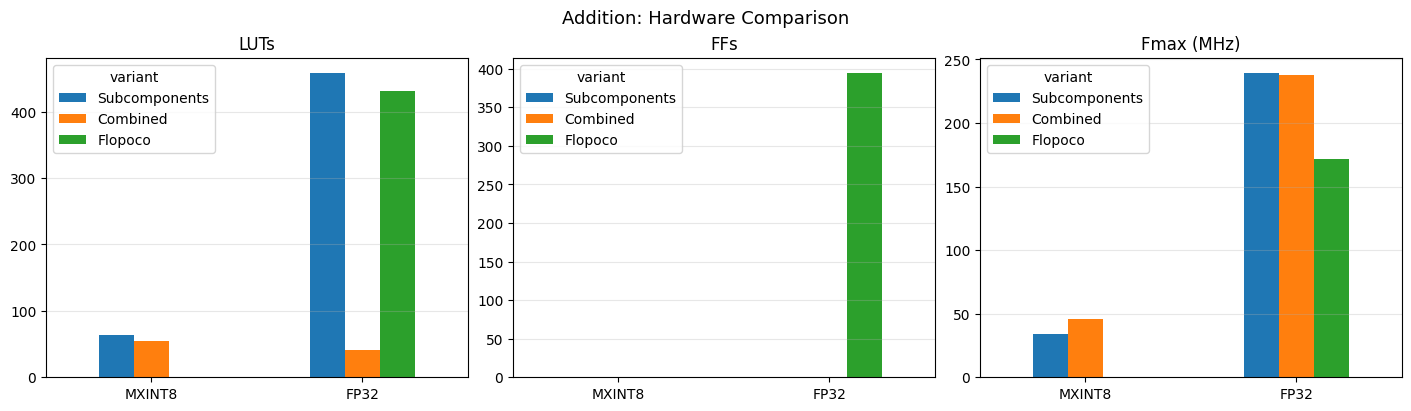

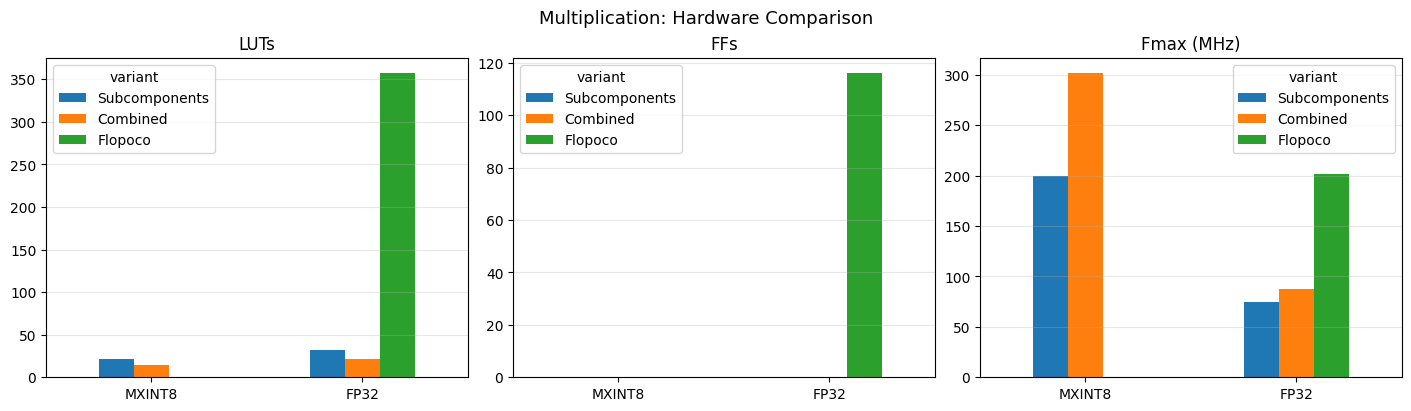

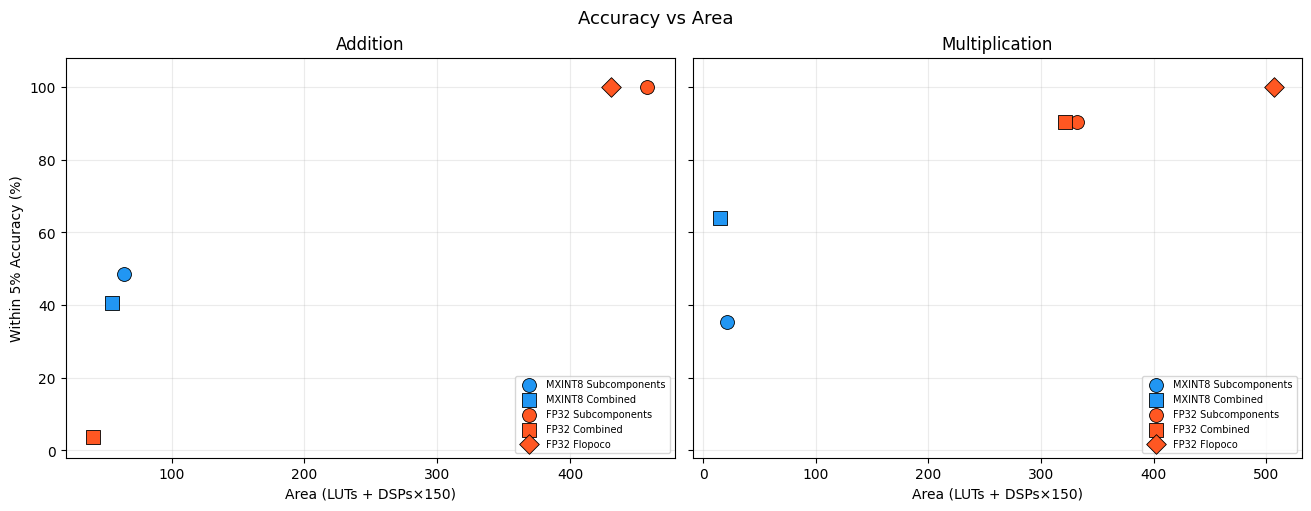

In [13]:
# Load results (from memory, cache, or reconstruct from pipeline log)
# Set FORCE_RECONSTRUCT = True to ignore in-memory results and re-parse from log
FORCE_RECONSTRUCT = True
if FORCE_RECONSTRUCT or "results" not in globals() or not results:
    cache = ROOT / "results" / "notebooks" / "latest_unified_results.json"
    pipeline_log = ROOT / "logs" / "pipeline.log"
    if cache.exists():
        results = json.loads(cache.read_text())
        print(f"Loaded from cache: {cache}")
    elif pipeline_log.exists():
        # Reconstruct results from tmux pipeline log
        print(f"Reconstructing results from {pipeline_log}")
        log_text = pipeline_log.read_text()
        results = []
        # Parse per-job sections from the log
        import re as _re
        _sections = _re.split(r'^===\s+', log_text, flags=_re.MULTILINE)
        _job_map = {}
        for sec in _sections[1:]:
            header = sec.split('===')[0].strip()
            _name = header.replace('FloPoCo: ', '').replace(' / ', '_').replace(' ', '_')
            _job_map[_name] = sec
        SYNTH_JOBS_DEF = [
            {"name": "mxint8_add_subcomponents", "key": "mxint8_add_full_sum", "op": "Addition", "dtype": "MXINT8", "variant": "Subcomponents", "soln": "solution_mxint8addition_full_sum", "top": "add_full_sum", "base": "HLS"},
            {"name": "mxint8_add_combined", "key": "mxint8_add_full_sum_combined", "op": "Addition", "dtype": "MXINT8", "variant": "Combined", "soln": "solution_mxint8addition_full_sum_combined", "top": "add_full_sum", "base": "HLS"},
            {"name": "mxint8_mul_subcomponents", "key": "mxint8_mul_full_product", "op": "Multiplication", "dtype": "MXINT8", "variant": "Subcomponents", "soln": "solution_mxint8multiplication_full_product", "top": "mult_mxint_full_product", "base": "HLS"},
            {"name": "mxint8_mul_combined", "key": "mxint8_mul_full_product_combined", "op": "Multiplication", "dtype": "MXINT8", "variant": "Combined", "soln": "solution_mxint8multiplication_full_product_combined", "top": "mult_mxint_full_product", "base": "HLS"},
            {"name": "fp32_add_subcomponents", "key": "fp32_add_full_sum", "op": "Addition", "dtype": "FP32", "variant": "Subcomponents", "soln": "solution_fp32addition_full_sum", "top": "fp32_sum", "base": "HLS"},
            {"name": "fp32_add_combined", "key": "fp32_add_full_sum_combined", "op": "Addition", "dtype": "FP32", "variant": "Combined", "soln": "solution_fp32addition_full_sum_combined", "top": "fp32_sum", "base": "HLS"},
            {"name": "fp32_mul_subcomponents", "key": "fp32_mul_full_product", "op": "Multiplication", "dtype": "FP32", "variant": "Subcomponents", "soln": "solution_fp32multiplication_full_product", "top": "fp32_full_mul", "base": "HLS"},
            {"name": "fp32_mul_combined", "key": "fp32_mul_full_product_combined", "op": "Multiplication", "dtype": "FP32", "variant": "Combined", "soln": "solution_fp32multiplication_full_product_combined", "top": "fp32_full_mul", "base": "HLS"},
            {"name": "fp32_add_flopoco", "key": "fp32_add_flopoco", "op": "Addition", "dtype": "FP32", "variant": "Flopoco", "soln": "solution_fp32addition_flopoco", "top": "fp32_sum_flopoco", "base": "FLOPOCO"},
            {"name": "fp32_mul_flopoco", "key": "fp32_mul_flopoco", "op": "Multiplication", "dtype": "FP32", "variant": "Flopoco", "soln": "solution_fp32multiplication_flopoco", "top": "fp32_full_mul_flopoco", "base": "FLOPOCO"},
        ]
        for job in SYNTH_JOBS_DEF:
            sec = _job_map.get(job["key"], "")
            metrics = extract_metrics(sec)
            acc_rc = parse_accuracy_rc_from_driver(sec)
            rc_line = _re.search(r'Return code: (\d+)', sec)
            pipeline_rc = int(rc_line.group(1)) if rc_line else None
            results.append({
                "name": job["name"], "op": job["op"], "dtype": job["dtype"],
                "variant": job["variant"], "soln": job["soln"], "top": job["top"],
                "base": job["base"], "pipeline_returncode": pipeline_rc,
                "returncode": acc_rc, "metrics": metrics,
            })
        # Save cache for next time
        cache.parent.mkdir(parents=True, exist_ok=True)
        cache.write_text(json.dumps(results, indent=2, default=str))
        print(f"Reconstructed {len(results)} results from pipeline log and saved to {cache}")
    else:
        raise RuntimeError("No results found. Run the pipeline cell or tmux pipeline session first.")
    # Merge FloPoCo results from Cell 4 if they exist in memory
    if "flopoco_results" in globals() and flopoco_results:
        flopoco_names = {r["name"] for r in flopoco_results}
        results = [r for r in results if r.get("name") not in flopoco_names] + flopoco_results
        print(f"Merged {len(flopoco_results)} FloPoCo results from Cell 4")
    else:
        print("Note: No FloPoCo results from Cell 4 — using pipeline log data for FloPoCo entries")


# Build accuracy dataframe (no ULP)
acc_rows = []
for r in results:
    m = r.get("metrics", {}) or {}
    tested, skipped = _parse_ran(m.get("ran"))
    row = {
        "name": r.get("name"), "op": r.get("op"), "dtype": r.get("dtype"),
        "variant": r.get("variant"),
        "status": "SKIP" if r.get("returncode") is None else ("PASS" if r.get("returncode") == 0 else "FAIL"),
        "tested": tested, "skipped": skipped,
        "quant_max_abs": np.nan, "quant_avg_abs": np.nan, "quant_p99": np.nan,
        "quant_pct_within_fs": np.nan,
        "full_max_abs": np.nan, "full_avg_abs": np.nan, "full_p99": np.nan,
        "full_pct_within_fs": np.nan,
    }
    max_abs = m.get("max_abs", [])
    avg_abs = m.get("avg_abs", [])
    p99 = m.get("p99", [])
    pctw = m.get("percent_within", [])
    fp32_inline = m.get("fp32_inline", [])
    # MXINT8 format (absolute error metrics)
    if len(max_abs) > 0: row["quant_max_abs"] = _parse_value_after_colon(max_abs[0])
    if len(avg_abs) > 0: row["quant_avg_abs"] = _parse_value_after_colon(avg_abs[0])
    if len(p99) > 0: row["quant_p99"] = _parse_value_after_colon(p99[0])
    if len(pctw) > 0: row["quant_pct_within_fs"] = _parse_percent_after_colon(pctw[0])
    if len(max_abs) > 1: row["full_max_abs"] = _parse_value_after_colon(max_abs[1])
    if len(avg_abs) > 1: row["full_avg_abs"] = _parse_value_after_colon(avg_abs[1])
    if len(p99) > 1: row["full_p99"] = _parse_value_after_colon(p99[1])
    if len(pctw) > 1: row["full_pct_within_fs"] = _parse_percent_after_colon(pctw[1])
    # FP32 inline format: "[IN-DIST ...] ... Exact match: X%. Within Y% relative error: Z%"
    for fp_line in fp32_inline:
        m_exact = re.search(r"Exact match:\s*([\d.]+)%", fp_line)
        m_within = re.search(r"Within\s+\d+%\s+relative error:\s*([\d.]+)%", fp_line)
        if "[IN-DIST" in fp_line:
            if m_exact: row["fp32_indist_exact"] = float(m_exact.group(1))
            if m_within: row["fp32_indist_within_rel"] = float(m_within.group(1))
        elif "[GENERALISATION" in fp_line:
            if m_exact: row["fp32_gen_exact"] = float(m_exact.group(1))
            if m_within: row["fp32_gen_within_rel"] = float(m_within.group(1))
    # Fallback: handle old-format metrics (within_rel, exact_match) from cached FloPoCo runs
    if not fp32_inline and "fp32_indist_within_rel" not in row:
        within_rel = m.get("within_rel", [])
        for wl in within_rel:
            m_within = re.search(r"Within\s+\d+%\s+relative error:\s*([\d.]+)%", wl)
            m_exact = re.search(r"Exact match:\s*([\d.]+)%", wl)
            if "[IN-DIST" in wl or (not any(t in wl for t in ["[GENERALISATION"])):
                if m_within: row["fp32_indist_within_rel"] = float(m_within.group(1))
                if m_exact: row["fp32_indist_exact"] = float(m_exact.group(1))
            elif "[GENERALISATION" in wl:
                if m_within: row["fp32_gen_within_rel"] = float(m_within.group(1))
                if m_exact: row["fp32_gen_exact"] = float(m_exact.group(1))
    acc_rows.append(row)

acc_df = pd.DataFrame(acc_rows).sort_values(["op", "dtype", "variant"]).reset_index(drop=True)

# Build hardware dataframe
QOR_TARGETS = [
    {"op": "Addition", "dtype": "MXINT8", "variant": "Subcomponents", "soln": "solution_mxint8addition_full_sum", "top": "add_full_sum", "base": "HLS"},
    {"op": "Addition", "dtype": "MXINT8", "variant": "Combined", "soln": "solution_mxint8addition_full_sum_combined", "top": "add_full_sum", "base": "HLS"},
    {"op": "Addition", "dtype": "FP32", "variant": "Subcomponents", "soln": "solution_fp32addition_full_sum", "top": "fp32_sum", "base": "HLS"},
    {"op": "Addition", "dtype": "FP32", "variant": "Combined", "soln": "solution_fp32addition_full_sum_combined", "top": "fp32_sum", "base": "HLS"},
    {"op": "Addition", "dtype": "FP32", "variant": "Flopoco", "soln": "solution_fp32addition_flopoco", "top": "fp32_sum_flopoco", "base": "FLOPOCO"},
    {"op": "Multiplication", "dtype": "MXINT8", "variant": "Subcomponents", "soln": "solution_mxint8multiplication_full_product", "top": "mult_mxint_full_product", "base": "HLS"},
    {"op": "Multiplication", "dtype": "MXINT8", "variant": "Combined", "soln": "solution_mxint8multiplication_full_product_combined", "top": "mult_mxint_full_product", "base": "HLS"},
    {"op": "Multiplication", "dtype": "FP32", "variant": "Subcomponents", "soln": "solution_fp32multiplication_full_product", "top": "fp32_full_mul", "base": "HLS"},
    {"op": "Multiplication", "dtype": "FP32", "variant": "Combined", "soln": "solution_fp32multiplication_full_product_combined", "top": "fp32_full_mul", "base": "HLS"},
    {"op": "Multiplication", "dtype": "FP32", "variant": "Flopoco", "soln": "solution_fp32multiplication_flopoco", "top": "fp32_full_mul_flopoco", "base": "FLOPOCO"},
]
hw_rows = []
for t in QOR_TARGETS:
    out_dir = ROOT / "results" / t["base"] / t["soln"]
    if not out_dir.exists():
        hw_rows.append({**t, "exists": False, "LUTs": np.nan, "FFs": np.nan, "DSPs": np.nan, "BRAMs": np.nan, "Cycles": np.nan, "Fmax_MHz": np.nan})
    else:
        hw = parse_reports(out_dir, t["top"], t["soln"], run_impl=True)
        hw_rows.append({**t, "exists": True, **hw})

qor_df = pd.DataFrame(hw_rows)

# Merge
merged = qor_df.merge(acc_df.drop(columns=["name"], errors="ignore"),
                       on=["op", "dtype", "variant"], how="left")

# Clean up: -1 means "not available" (e.g. combinational designs have no clock)
for col in ["Fmax_MHz", "LUTs", "FFs", "DSPs", "BRAMs", "Cycles"]:
    if col in merged.columns:
        merged[col] = merged[col].replace(-1, np.nan)

# Unified within-5% accuracy: quant_pct_within_fs for MXINT8, fp32_indist_within_rel for FP32
_fp32_within = merged["fp32_indist_within_rel"] if "fp32_indist_within_rel" in merged.columns else np.nan
merged["within5pct"] = np.where(merged["dtype"] == "MXINT8", merged["quant_pct_within_fs"], _fp32_within)

_suppress = {"top", "soln", "base", "exists", "name", "skipped",
             "quant_pct_within_fs", "full_pct_within_fs",
             "quant_max_abs", "quant_avg_abs", "quant_p99",
             "full_max_abs", "full_avg_abs", "full_p99"}
front_cols = [c for c in [
    "op", "dtype", "variant", "status", "tested",
    "LUTs", "FFs", "DSPs", "BRAMs", "Fmax_MHz",
    "within5pct",
    "fp32_indist_exact", "fp32_indist_within_rel",
    "fp32_gen_exact", "fp32_gen_within_rel",
] if c in merged.columns]
other = [c for c in merged.columns if c not in front_cols and c not in _suppress]
view = merged[front_cols + other].sort_values(["op", "dtype", "variant"]).reset_index(drop=True)

print("Unified hardware + accuracy summary")
display(view)

# ──── Bar charts: LUTs, FFs, Fmax by op ────
for op in ["Addition", "Multiplication"]:
    d = qor_df[(qor_df["op"] == op) & (qor_df.get("exists", True))].copy()
    if d.empty:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    for ax, (col, title) in zip(axes, [("LUTs", "LUTs"), ("FFs", "FFs"), ("Fmax_MHz", "Fmax (MHz)")]):
        p = d.pivot(index="dtype", columns="variant", values=col).reindex(["MXINT8", "FP32"])
        p = p.reindex(columns=[v for v in ["Subcomponents", "Combined", "Flopoco"] if v in p.columns])
        p.plot(kind="bar", ax=ax, rot=0)
        ax.set_title(title); ax.set_xlabel(""); ax.grid(axis="y", alpha=0.3)
    fig.suptitle(f"{op}: Hardware Comparison", fontsize=13)
    plt.show()

# ──── Accuracy vs Area scatter (per operation) ────
plot_df = merged.dropna(subset=["LUTs", "within5pct"]).copy()
plot_df["LUTs_equiv"] = plot_df["LUTs"] + plot_df["DSPs"].fillna(0) * 150
plot_df["accuracy"] = plot_df["within5pct"]

markers = {"Subcomponents": "o", "Combined": "s", "Flopoco": "D"}
colors = {"MXINT8": "#2196F3", "FP32": "#FF5722"}

if not plot_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)
    for ax, op in zip(axes, ["Addition", "Multiplication"]):
        d = plot_df[plot_df["op"] == op]
        for _, row in d.iterrows():
            ax.scatter(row["LUTs_equiv"], row["accuracy"],
                       marker=markers.get(row["variant"], "x"),
                       color=colors.get(row["dtype"], "gray"),
                       s=100, edgecolors="black", linewidth=0.6, zorder=5,
                       label=f"{row['dtype']} {row['variant']}")
        ax.set_xlabel("Area (LUTs + DSPs×150)")
        ax.set_title(f"{op}")
        ax.set_ylim(-2, 108); ax.grid(alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=7, loc="lower right")
    axes[0].set_ylabel("Within 5% Accuracy (%)")
    fig.suptitle("Accuracy vs Area", fontsize=13)
    plt.show()

# 2. Hyperparameter Sweep

Sweeps solver `timeout` and `num_iterations` to find the optimal balance for each synthesis target.
Supports 1D sweeps (`timeout-sweep`, `iter-sweep`) and 2D joint grid (`joint`).
Uses `--patience` for early stopping when metrics plateau.

In [ ]:
# ──────── Hyperparameter Sweep Runner ────────
# Quality sweep: measures accuracy + area (HLS-estimated LUTs) per (timeout, iterations) config.
# Grid is intentionally coarse (3×3 = 9 points) to keep the run tractable (~14 hrs overnight).
# HLS implementation (place-and-route) is skipped; HLS synthesis estimates are sufficient
# for comparing configs. Full P&R is only needed for the final pipeline run.
HP_BENCHMARKS = [
    "mxint8_add_combined", "mxint8_add_sub",
    "mxint8_mul_combined", "mxint8_mul_sub",
    "fp32_add_combined",   "fp32_add_sub",
    "fp32_mul_combined",   "fp32_mul_sub",
]
HP_MODE = "joint"
HP_TIMEOUTS = [10, 60, 300]    # coarse: fast / medium / long
HP_ITERATIONS = [5, 15, 30]    # coarse: few / medium / many
HP_REPETITIONS = 3
HP_PATIENCE = 0                # disable early stopping — quality can be non-monotone
HP_OUTPUT_DIR = "results/hyperparameter_sweep/quality_joint"

cmd = [
    sys.executable, "-m", "src.Experiments.hyperparameter_sweep", HP_MODE,
    "--benchmarks", *HP_BENCHMARKS,
    "--timeouts", *[str(t) for t in HP_TIMEOUTS],
    "--iterations", *[str(i) for i in HP_ITERATIONS],
    "--repetitions", str(HP_REPETITIONS),
    "--patience", str(HP_PATIENCE),
    "--output-dir", HP_OUTPUT_DIR,
    "--run-accuracy",          # run HLS synthesis + cocotb accuracy per solved point
]

print("Command:", " ".join(cmd))
print(f"Total runs: {len(HP_BENCHMARKS)} benchmarks × {len(HP_TIMEOUTS)*len(HP_ITERATIONS)} points × {HP_REPETITIONS} reps = "
      f"{len(HP_BENCHMARKS) * len(HP_TIMEOUTS) * len(HP_ITERATIONS) * HP_REPETITIONS}")
proc = subprocess.run(cmd, cwd=ROOT)
print("Return code:", proc.returncode)

In [ ]:
# ──────── Hyperparameter Sweep Analysis ────────
hp_dir = ROOT / HP_OUTPUT_DIR if "HP_OUTPUT_DIR" in dir() else ROOT / "results" / "hyperparameter_sweep" / "quality_joint"
hp_jsonl = hp_dir / "runs.jsonl"

if not hp_jsonl.exists():
    for candidate in sorted((ROOT / "results" / "hyperparameter_sweep").glob("*/runs.jsonl")):
        hp_jsonl = candidate
        hp_dir = candidate.parent
        break

if not hp_jsonl.exists():
    raise FileNotFoundError("No hyperparameter sweep results found. Run the sweep cell first.")

hp_rows = [json.loads(line) for line in hp_jsonl.read_text().strip().split("\n") if line.strip()]
hp_df = pd.DataFrame(hp_rows)
for col in ["accepted_constraints", "solver_runtime_seconds_total", "wall_seconds", "within_rel_pct", "luts", "fmax_mhz", "latency_ns"]:
    if col in hp_df.columns:
        hp_df[col] = pd.to_numeric(hp_df[col], errors="coerce")
        hp_df.loc[hp_df[col] < 0, col] = np.nan

has_accuracy = "within_rel_pct" in hp_df.columns and hp_df["within_rel_pct"].notna().any()
has_luts     = "luts" in hp_df.columns and hp_df["luts"].notna().any()
has_fmax     = "fmax_mhz" in hp_df.columns and hp_df["fmax_mhz"].notna().any()
print(f"Loaded {len(hp_df)} runs from {hp_jsonl}")
print(f"Accuracy available: {has_accuracy}   LUT data available: {has_luts}   Fmax available: {has_fmax}")

# ──── Aggregate per (benchmark, timeout, iterations) ────
agg_rows = []
for bench in hp_df["benchmark"].unique():
    bdf = hp_df[hp_df["benchmark"] == bench]
    for (t, i), gdf in bdf.groupby(["timeout", "num_iterations"]):
        within = gdf["within_rel_pct"].dropna().tolist() if has_accuracy else []
        luts   = gdf["luts"].dropna().tolist() if has_luts else []
        mean_acc  = float(np.mean(within)) if within else np.nan
        mean_luts = float(np.mean(luts))   if luts   else np.nan
        # Composite: normalise within-benchmark so both axes are [0,1], then sum.
        # Done after building the full agg table (see normalisation step below).
        agg_rows.append({
            "benchmark": bench, "timeout": int(t), "num_iterations": int(i),
            "solve_rate": gdf["solution_found"].mean(),
            "mean_accepted": gdf["accepted_constraints"].mean(),
            "mean_wall": gdf["wall_seconds"].mean(),
            "mean_within_rel_pct": mean_acc,
            "mean_luts": mean_luts,
            "mean_fmax_mhz": float(np.mean(gdf["fmax_mhz"].dropna().tolist())) if has_fmax and gdf["fmax_mhz"].dropna().size > 0 else np.nan,
            "mean_latency_ns": float(np.mean(gdf["latency_ns"].dropna().tolist())) if has_fmax and gdf["latency_ns"].dropna().size > 0 else np.nan,
        })

agg = pd.DataFrame(agg_rows)

# Normalise per benchmark, then compute composite score = acc_norm - lut_norm
# (higher is better: maximise accuracy, minimise area)
for bench in agg["benchmark"].unique():
    mask = agg["benchmark"] == bench
    acc_vals  = agg.loc[mask, "mean_within_rel_pct"]
    lut_vals  = agg.loc[mask, "mean_luts"]
    acc_range = acc_vals.max() - acc_vals.min()
    lut_range = lut_vals.max() - lut_vals.min()
    agg.loc[mask, "acc_norm"]  = (acc_vals  - acc_vals.min())  / acc_range  if acc_range  > 0 else 0.5
    agg.loc[mask, "lut_norm"]  = (lut_vals  - lut_vals.min())  / lut_range  if lut_range  > 0 else 0.5
    agg.loc[mask, "composite"] = agg.loc[mask, "acc_norm"] - agg.loc[mask, "lut_norm"]

# ──── Best parameters per benchmark ────
best_rows = []
rank_col = "composite" if (has_accuracy and has_luts) else ("mean_within_rel_pct" if has_accuracy else "mean_accepted")
for bench in agg["benchmark"].unique():
    bdf = agg[agg["benchmark"] == bench].dropna(subset=[rank_col])
    if bdf.empty:
        continue
    best = bdf.loc[bdf[rank_col].idxmax()]
    best_rows.append({
        "Benchmark":           bench,
        "Best Timeout (s)":    int(best["timeout"]),
        "Best Iterations":     int(best["num_iterations"]),
        "Solve Rate":          f"{best['solve_rate']:.0%}",
        "Mean Accuracy (5%)":  f"{best['mean_within_rel_pct']*100:.1f}%" if not np.isnan(best['mean_within_rel_pct']) else "N/A",
        "Mean LUTs (est.)":    f"{best['mean_luts']:.0f}"  if not np.isnan(best['mean_luts']) else "N/A",
        "Mean Fmax (MHz)":     f"{best['mean_fmax_mhz']:.1f}" if not np.isnan(best.get('mean_fmax_mhz', np.nan)) else "N/A",
        "Mean Latency (ns)":   f"{best['mean_latency_ns']:.3f}" if not np.isnan(best.get('mean_latency_ns', np.nan)) else "N/A",
        "Composite Score":     f"{best['composite']:.3f}"  if not np.isnan(best.get('composite', np.nan)) else "N/A",
        "Ranked By":           rank_col,
    })

print(f"\nBest hyperparameters per benchmark (ranked by: {rank_col})")
display(pd.DataFrame(best_rows))

benchmarks = sorted(hp_df["benchmark"].unique())
n_bench = len(benchmarks)
ncols = min(n_bench, 4)
nrows = (n_bench + ncols - 1) // ncols

def _heatmap(ax, bench, col, label, cmap, vmin=None, vmax=None, scale=1.0, fmt=".1f"):
    bdf = hp_df[hp_df["benchmark"] == bench]
    pivot = bdf.pivot_table(index="timeout", columns="num_iterations", values=col, aggfunc="mean")
    vals = pivot.values * scale
    im = ax.imshow(vals, aspect="auto", cmap=cmap, origin="lower",
                   interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns.astype(int), fontsize=8)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index.astype(int),   fontsize=8)
    ax.set_xlabel("Iterations"); ax.set_ylabel("Timeout (s)")
    ax.set_title(bench.replace("_", " ").title(), fontsize=10)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if not np.isnan(v):
                normed = (v - (vmin or 0)) / ((vmax or 1) - (vmin or 0))
                color = "white" if normed < 0.3 or normed > 0.7 else "black"
                ax.text(j, i, format(v, fmt), ha="center", va="center", fontsize=7, color=color)
    plt.colorbar(im, ax=ax, shrink=0.8, label=label)

# ── Accuracy heatmap ──
if has_accuracy:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
    for idx, bench in enumerate(benchmarks):
        _heatmap(axes[idx//ncols][idx%ncols], bench, "within_rel_pct", "Within 5% (%)", "RdYlGn", 0, 1, 100, ".0f")
    for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
    fig.suptitle("Accuracy: Mean Within-5% per Config", fontsize=14); plt.show()

# ── LUT heatmap ──
if has_luts:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
    for idx, bench in enumerate(benchmarks):
        _heatmap(axes[idx//ncols][idx%ncols], bench, "luts", "LUTs (est.)", "RdYlGn_r", fmt=".0f")
    for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
    fig.suptitle("Area: Mean HLS-Estimated LUTs per Config", fontsize=14); plt.show()
# ── Fmax / Latency heatmaps ──
if has_fmax:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
    for idx, bench in enumerate(benchmarks):
        _heatmap(axes[idx//ncols][idx%ncols], bench, "fmax_mhz", "Fmax (MHz)", "RdYlGn", fmt=".0f")
    for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
    fig.suptitle("Fmax: Mean HLS-Estimated Fmax (MHz) per Config", fontsize=14); plt.show()

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
    for idx, bench in enumerate(benchmarks):
        _heatmap(axes[idx//ncols][idx%ncols], bench, "latency_ns", "Latency (ns)", "RdYlGn_r", fmt=".2f")
    for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
    fig.suptitle("Latency: Mean HLS-Estimated Latency (ns) per Config", fontsize=14); plt.show()

# ── Composite score heatmap ──
if has_accuracy and has_luts:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
    for idx, bench in enumerate(benchmarks):
        bagg = agg[agg["benchmark"] == bench]
        pivot = bagg.pivot_table(index="timeout", columns="num_iterations", values="composite")
        ax = axes[idx//ncols][idx%ncols]
        vals = pivot.values
        im = ax.imshow(vals, aspect="auto", cmap="RdYlGn", origin="lower",
                       interpolation="nearest", vmin=-1, vmax=1)
        ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns.astype(int), fontsize=8)
        ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index.astype(int),   fontsize=8)
        ax.set_xlabel("Iterations"); ax.set_ylabel("Timeout (s)")
        ax.set_title(bench.replace("_", " ").title(), fontsize=10)
        # Mark the best cell
        if not np.all(np.isnan(vals)):
            best_idx = np.unravel_index(np.nanargmax(vals), vals.shape)
            ax.add_patch(plt.Rectangle((best_idx[1]-0.5, best_idx[0]-0.5), 1, 1,
                                       fill=False, edgecolor="blue", linewidth=2.5))
        for i in range(vals.shape[0]):
            for j in range(vals.shape[1]):
                v = vals[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                            color="black" if -0.5 < v < 0.5 else "white")
        plt.colorbar(im, ax=ax, shrink=0.8, label="acc_norm − lut_norm")
    for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
    fig.suptitle("Composite Score: Accuracy − Area (blue border = best per benchmark)", fontsize=14)
    plt.show()

# ── Pareto scatter: accuracy vs LUTs ──
if has_accuracy and has_luts:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
    for idx, bench in enumerate(benchmarks):
        ax = axes[idx//ncols][idx%ncols]
        bagg = agg[agg["benchmark"] == bench].dropna(subset=["mean_within_rel_pct", "mean_luts"])
        sc = ax.scatter(bagg["mean_luts"], bagg["mean_within_rel_pct"]*100,
                        c=bagg["timeout"], cmap="coolwarm", s=70, edgecolors="black",
                        linewidth=0.4, zorder=5)
        # Pareto front (non-dominated: no other point has both higher accuracy AND fewer LUTs)
        pts = bagg[["mean_luts", "mean_within_rel_pct"]].values
        pareto = []
        for i, (l, a) in enumerate(pts):
            if not any(pts[j,0] <= l and pts[j,1] >= a and (pts[j,0] < l or pts[j,1] > a)
                       for j in range(len(pts)) if j != i):
                pareto.append((l, a, bagg.iloc[i]["timeout"], bagg.iloc[i]["num_iterations"]))
        if pareto:
            pareto.sort()
            ax.plot([p[0] for p in pareto], [p[1]*100 for p in pareto],
                    "k--", linewidth=1.5, alpha=0.7, label="Pareto front")
            for l, a, t_, i_ in pareto:
                ax.annotate(f"t{int(t_)}i{int(i_)}", (l, a*100),
                            textcoords="offset points", xytext=(4, 4), fontsize=6)
        ax.set_xlabel("Mean LUTs (HLS est.)"); ax.set_ylabel("Mean Accuracy (Within 5%)")
        ax.set_ylim(-2, 105)
        ax.set_title(bench.replace("_", " ").title(), fontsize=10)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
        plt.colorbar(sc, ax=ax, shrink=0.7, label="timeout (s)")
    for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
    fig.suptitle("Pareto Front: Area vs Accuracy per Config\n(Pareto-optimal = dashed line)", fontsize=14)
    plt.show()

# ── Solve rate heatmap (always shown) ──
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
for idx, bench in enumerate(benchmarks):
    _heatmap(axes[idx//ncols][idx%ncols], bench, "solution_found", "Solve Rate", "RdYlGn", 0, 1, 100, ".0f")
for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
fig.suptitle("Solve Rate per Config", fontsize=14); plt.show()

# 3. Grammar Selection Study

V1 (broad, more productions) vs V2 (tight structural sketch). Compares synthesis speed, hardware cost, and accuracy across all combined benchmarks.

In [ ]:
GS_DIR = ROOT / "results" / "grammar_selection"
gs_jsonl = GS_DIR / "runs.jsonl"
if not gs_jsonl.exists():
    raise FileNotFoundError(f"Grammar selection results not found at {gs_jsonl}.\n"
                            "Run: python -m src.Experiments.grammar_selection_study ...")

gs_runs = [json.loads(line) for line in gs_jsonl.read_text().strip().split("\n")]
gs_df = pd.DataFrame(gs_runs)

for col in ["LUTs", "FFs", "Fmax_MHz", "Latency_ns", "accuracy_exact_match", "within_rel_pct",
            "solver_runtime_seconds_total", "enum_count_primary_total",
            "accepted_constraints", "total_constraints",
            "abs_err_avg", "abs_err_max", "abs_err_p99"]:
    if col in gs_df.columns:
        gs_df[col] = pd.to_numeric(gs_df[col], errors="coerce")
        gs_df.loc[gs_df[col] < 0, col] = np.nan

gs_summary = json.loads((GS_DIR / "summary.json").read_text())
gs_sdf = pd.DataFrame(gs_summary)

label_map = {
    "mxint8_add": "MXINT8 Addition", "mxint8_mul": "MXINT8 Multiplication",
    "fp32_add": "FP32 Addition", "fp32_mul": "FP32 Multiplication",
}
gs_df["label"] = gs_df["benchmark"].map(label_map).fillna(gs_df["benchmark"])
gs_sdf["label"] = gs_sdf["benchmark"].map(label_map).fillna(gs_sdf["benchmark"])

# ──── Table 1: Aggregate summary ────
summary_cols = {
    "label": "Benchmark", "grammar_version": "Grammar", "num_subcomponents": "# Grammars",
    "mean_runtime_seconds": "Mean Runtime (s)",
    "mean_enum_count": "Mean Enum Terms", "mean_LUTs": "Mean LUTs",
    "mean_Fmax_MHz": "Mean Fmax (MHz)",
    "mean_Latency_ns": "Mean Latency (ns)",
    "mean_within_rel_pct": "Within Rel %",
    "total_productions": "Grammar Productions", "branching_nonterminals": "Branching NTs",
}
available = {k: v for k, v in summary_cols.items() if k in gs_sdf.columns}
tbl = gs_sdf[list(available.keys())].rename(columns=available).copy()
if "Mean Runtime (s)" in tbl.columns:
    tbl["Mean Runtime (s)"] = tbl["Mean Runtime (s)"].map(lambda x: f"{x:,.1f}" if pd.notna(x) else "\u2014")
if "Mean Enum Terms" in tbl.columns:
    tbl["Mean Enum Terms"] = tbl["Mean Enum Terms"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "\u2014")
if "Within Rel %" in tbl.columns:
    tbl["Within Rel %"] = tbl["Within Rel %"].map(lambda x: f"{x*100:.1f}%" if pd.notna(x) else "\u2014")

print("Grammar Selection Study: V1 (broad) vs V2 (tight sketch) vs Subcomponents")
print("=" * 80)
display(tbl)

# LaTeX export
latex_str = tbl.to_latex(index=False, escape=True)
print("\nLaTeX table:\n")
print(latex_str)

# ──── Table 2: Per-run detail ────
detail_cols = ["label", "grammar_version", "num_subcomponents", "repetition",
               "accepted_constraints", "total_constraints",
               "solver_runtime_seconds_total", "enum_count_primary_total",
               "LUTs", "Fmax_MHz", "Latency_ns", "within_rel_pct"]
detail_cols = [c for c in detail_cols if c in gs_df.columns]
detail = gs_df[detail_cols].sort_values(["label", "grammar_version", "repetition"]).reset_index(drop=True)
detail.columns = [c.replace("_", " ").title() for c in detail.columns]
print("\nPer-run detail")
display(detail)

# ──── Charts: 2x3 comparison ────
benchmarks = gs_df["label"].unique()
versions = ["V1", "V2", "Subcomponents"]
colours = {"V1": "#e07b54", "V2": "#5b9bd5", "Subcomponents": "#6abf69"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
chart_specs = [
    ("solver_runtime_seconds_total", "Solver Runtime (s)", True),
    ("enum_count_primary_total", "Enumerated Terms", True),
    ("accepted_constraints", "Accepted Constraints", False),
    ("LUTs", "LUTs (post-impl)", False),
    ("Fmax_MHz", "Fmax (MHz)", False),
    ("within_rel_pct", "Within Threshold (%)", False),
]
n_ver = len(versions)
for ax, (col, title, use_log) in zip(axes.flat, chart_specs):
    if col not in gs_df.columns:
        ax.set_visible(False); continue
    x = np.arange(len(benchmarks))
    width = 0.22
    for i, ver in enumerate(versions):
        subset = gs_df[gs_df["grammar_version"] == ver]
        means = [subset[subset["label"] == b][col].mean() for b in benchmarks]
        stds = [subset[subset["label"] == b][col].std() for b in benchmarks]
        offset = (i - (n_ver - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=stds, label=ver,
               color=colours[ver], capsize=3, edgecolor="white", linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(benchmarks, fontsize=9, rotation=15, ha="right")
    ax.set_title(title, fontsize=11); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    if use_log: ax.set_yscale("log")
fig.suptitle("Grammar Selection: V1 (Broad) vs V2 (Structural Sketch) vs Subcomponents", fontsize=13, fontweight="bold")
plt.show()

# ──── Cross-version comparison table ────
ratio_rows = []
for bench in benchmarks:
    def _mean_rt(ver): return gs_df[(gs_df["label"] == bench) & (gs_df["grammar_version"] == ver)]["solver_runtime_seconds_total"].mean()
    def _mean_en(ver): return gs_df[(gs_df["label"] == bench) & (gs_df["grammar_version"] == ver)]["enum_count_primary_total"].mean()
    rt1, rt2, rts = _mean_rt("V1"), _mean_rt("V2"), _mean_rt("Subcomponents")
    en1, en2, ens = _mean_en("V1"), _mean_en("V2"), _mean_en("Subcomponents")
    ratio_rows.append({
        "Benchmark": bench,
        "V1 Runtime (s)": f"{rt1:,.1f}" if pd.notna(rt1) else "\u2014",
        "V2 Runtime (s)": f"{rt2:,.1f}" if pd.notna(rt2) else "\u2014",
        "Sub Runtime (s)": f"{rts:,.1f}" if pd.notna(rts) else "\u2014",
        "V2 Speedup vs V1": f"{rt1/rt2:,.1f}x" if pd.notna(rt1) and pd.notna(rt2) and rt2 > 0 else "\u2014",
        "Sub Speedup vs V1": f"{rt1/rts:,.1f}x" if pd.notna(rt1) and pd.notna(rts) and rts > 0 else "\u2014",
        "V1 Enum Terms": f"{en1:,.0f}" if pd.notna(en1) else "\u2014",
        "V2 Enum Terms": f"{en2:,.0f}" if pd.notna(en2) else "\u2014",
        "Sub Enum Terms": f"{ens:,.0f}" if pd.notna(ens) else "\u2014",
    })
if ratio_rows:
    print("\nCross-version runtime & enumeration comparison")
    display(pd.DataFrame(ratio_rows))

# 4. Ablation Study

Factorial ablation measuring the contribution of each technique:
- **CVC5**: Our synthesiser's output vs FloPoCo's human-designed hardware
- **Relaxation**: Staged MSB constraint relaxation
- **BV Search**: Bitvector width optimisation (mantissa truncation)

| Config | Source | Relaxation | BV Search |
|--------|--------|------------|-----------|
| FloPoCo baseline | FloPoCo | - | - |
| FloPoCo + BV | FloPoCo | - | ✓ |
| CVC5 only | CVC5 | - | - |
| CVC5 + Relaxation | CVC5 | ✓ | - |
| CVC5 + BV | CVC5 | - | ✓ |
| CVC5 + Relaxation + BV | CVC5 | ✓ | ✓ |

In [ ]:
# ──────── Ablation Study: Factorial Table ────────
# Build one row per (op, dtype, config) combination.
# Configs: FloPoCo, FloPoCo+BV, CVC5, CVC5+Relax, CVC5+BV, CVC5+Relax+BV

if "merged" not in globals():
    raise RuntimeError("Run Section 1 first to populate merged dataframe.")

# Helper: find best BV sweep result for a given family + target
def _best_bv(bv_dataframe, family, target_key_pattern):
    """Return (LUTs, accuracy) for the best BV sweep point, or (nan, nan)."""
    if bv_dataframe is None or bv_dataframe.empty:
        return np.nan, np.nan, np.nan, np.nan
    acc_col = "within_rel_pct" if "within_rel_pct" in bv_dataframe.columns else "accuracy_exact_match"
    target_col = "target_key" if "target_key" in bv_dataframe.columns else None
    mask = bv_dataframe["family"] == family
    if target_col and target_key_pattern:
        mask = mask & bv_dataframe[target_col].str.contains(target_key_pattern, case=False, na=False)
    subset = bv_dataframe[mask].dropna(subset=[acc_col, "LUTs"])
    if subset.empty:
        return np.nan, np.nan, np.nan, np.nan
    best = subset.loc[subset[acc_col].idxmax()]
    acc_val = best[acc_col] * 100 if best[acc_col] <= 1.0 else best[acc_col]
    return best.get("LUTs", np.nan), best.get("FFs", np.nan), best.get("DSPs", np.nan), acc_val

# Helper: check if relaxation was used for a CVC5 solution
def _get_relaxation_info(solution_name):
    """Check synthesis_summary.json for relaxation data."""
    summary_path = ROOT / "results" / "HLS" / solution_name / "synthesis_summary.json"
    if not summary_path.exists():
        return False, 0, 0
    try:
        s = json.loads(summary_path.read_text())
    except Exception:
        return False, 0, 0
    for comp in s.get("components", {}).values():
        attempts = comp.get("attempts", [])
        bits_vals = [a.get("bits", -1) for a in attempts if a.get("bits", -1) > 0]
        if bits_vals and max(bits_vals) > min(bits_vals):
            return True, max(bits_vals), min(bits_vals)
    return False, 0, 0

# BV data (may not exist yet)
_bv = globals().get("bv_df", pd.DataFrame())

# Target mapping for BV lookup
bv_target_patterns = {
    ("Addition", "MXINT8"): "mxint8_add",
    ("Addition", "FP32"): "fp32_add",
    ("Multiplication", "MXINT8"): "mxint8_mul",
    ("Multiplication", "FP32"): "fp32_mul",
}

ablation_rows = []

for op in ["Addition", "Multiplication"]:
    for dtype in ["MXINT8", "FP32"]:
        bv_pat = bv_target_patterns.get((op, dtype), "")

        # --- FloPoCo baseline (FP32 only) ---
        if dtype == "FP32":
            fp_row = merged[(merged["op"] == op) & (merged["dtype"] == dtype) & (merged["variant"] == "Flopoco")]
            if not fp_row.empty:
                r = fp_row.iloc[0]
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "FloPoCo",
                    "Source": "FloPoCo", "Relaxation": "-", "BV Search": "-",
                    "LUTs": r.get("LUTs"), "FFs": r.get("FFs"), "DSPs": r.get("DSPs"),
                    "Fmax_MHz": r.get("Fmax_MHz"),
                    "Accuracy (%)": r.get("quant_pct_within_fs", r.get("full_pct_within_fs")),
                })

            # --- FloPoCo + BV ---
            bv_luts, bv_ffs, bv_dsps, bv_acc = _best_bv(_bv, "flopoco", bv_pat)
            if not np.isnan(bv_acc):
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "FloPoCo + BV",
                    "Source": "FloPoCo", "Relaxation": "-", "BV Search": "Yes",
                    "LUTs": bv_luts, "FFs": bv_ffs, "DSPs": bv_dsps,
                    "Fmax_MHz": np.nan,
                    "Accuracy (%)": bv_acc,
                })

        # --- CVC5 only (subcomponents, no relaxation) ---
        cvc5_row = merged[(merged["op"] == op) & (merged["dtype"] == dtype) & (merged["variant"] == "Subcomponents")]
        if not cvc5_row.empty:
            r = cvc5_row.iloc[0]
            soln_name = r.get("soln", "") if "soln" in r.index else ""
            has_relax, max_b, min_b = _get_relaxation_info(soln_name) if soln_name else (False, 0, 0)

            ablation_rows.append({
                "Op": op, "Dtype": dtype, "Config": "CVC5",
                "Source": "CVC5", "Relaxation": "-", "BV Search": "-",
                "LUTs": r.get("LUTs"), "FFs": r.get("FFs"), "DSPs": r.get("DSPs"),
                "Fmax_MHz": r.get("Fmax_MHz"),
                "Accuracy (%)": r.get("quant_pct_within_fs", r.get("full_pct_within_fs")),
            })

            # --- CVC5 + Relaxation ---
            # Combined variant typically uses relaxation for FP32
            cvc5_combined = merged[(merged["op"] == op) & (merged["dtype"] == dtype) & (merged["variant"] == "Combined")]
            if not cvc5_combined.empty:
                rc = cvc5_combined.iloc[0]
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "CVC5 + Relaxation",
                    "Source": "CVC5", "Relaxation": "Yes", "BV Search": "-",
                    "LUTs": rc.get("LUTs"), "FFs": rc.get("FFs"), "DSPs": rc.get("DSPs"),
                    "Fmax_MHz": rc.get("Fmax_MHz"),
                    "Accuracy (%)": rc.get("quant_pct_within_fs", rc.get("full_pct_within_fs")),
                })

            # --- CVC5 + BV ---
            bv_luts, bv_ffs, bv_dsps, bv_acc = _best_bv(_bv, "synthesised", bv_pat)
            if not np.isnan(bv_acc):
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "CVC5 + BV",
                    "Source": "CVC5", "Relaxation": "-", "BV Search": "Yes",
                    "LUTs": bv_luts, "FFs": bv_ffs, "DSPs": bv_dsps,
                    "Fmax_MHz": np.nan,
                    "Accuracy (%)": bv_acc,
                })

                # --- CVC5 + Relaxation + BV ---
                # Use combined variant's relaxation + BV sweep
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "CVC5 + Relax + BV",
                    "Source": "CVC5", "Relaxation": "Yes", "BV Search": "Yes",
                    "LUTs": bv_luts, "FFs": bv_ffs, "DSPs": bv_dsps,
                    "Fmax_MHz": np.nan,
                    "Accuracy (%)": bv_acc,
                })

if ablation_rows:
    abl_df = pd.DataFrame(ablation_rows)
    # Compute LUT equivalents
    abl_df["LUT_equiv"] = abl_df["LUTs"].fillna(0) + abl_df["DSPs"].fillna(0) * 150

    display_cols = ["Op", "Dtype", "Config", "Source", "Relaxation", "BV Search",
                    "LUTs", "FFs", "DSPs", "Fmax_MHz", "Accuracy (%)", "LUT_equiv"]
    display_cols = [c for c in display_cols if c in abl_df.columns]

    print("Ablation Study: Factorial Comparison")
    print("=" * 100)
    display(abl_df[display_cols].reset_index(drop=True))

    # ──── Chart: LUT equiv vs Accuracy per target ────
    for op in ["Addition", "Multiplication"]:
        odf = abl_df[abl_df["Op"] == op].dropna(subset=["LUT_equiv", "Accuracy (%)"])
        if odf.empty:
            continue
        fig, ax = plt.subplots(figsize=(8, 5))
        dtype_colors = {"MXINT8": "#2196F3", "FP32": "#FF5722"}
        source_markers = {"FloPoCo": "D", "CVC5": "o"}
        for _, row in odf.iterrows():
            ax.scatter(row["LUT_equiv"], row["Accuracy (%)"],
                       marker=source_markers.get(row["Source"], "x"),
                       color=dtype_colors.get(row["Dtype"], "gray"),
                       s=80, edgecolors="black", linewidth=0.5)
            ax.annotate(row["Config"], (row["LUT_equiv"], row["Accuracy (%)"]),
                        fontsize=7, xytext=(5, 3), textcoords="offset points")
        for s, m in source_markers.items():
            ax.scatter([], [], marker=m, color="gray", label=s, edgecolors="black")
        for d, c in dtype_colors.items():
            ax.scatter([], [], marker="o", color=c, label=d, edgecolors="black")
        ax.set_xlabel("Area (LUT equivalents)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_title(f"Ablation: {op}")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        plt.show()
else:
    print("No ablation data available. Run Section 1 first.")

## 4b. Constraint Relaxation Analysis

In [ ]:
# Load synthesis summary JSONs and extract relaxation info from per-attempt data.
# Each attempt has a "bits" field showing the MSB match level.

SUMMARY_GLOBS = [
    ROOT / "results" / "notebooks" / "latest_unified_results.json",
]
# Also scan raw hyperparameter sweep summaries for relaxation data.
relax_rows = []

for summary_dir in sorted((ROOT / "results" / "HLS").glob("solution_*")):
    # Look for the synthesis summary JSON inside each solution dir
    for summary_file in summary_dir.glob("synthesis_summary.json"):
        try:
            s = json.loads(summary_file.read_text())
        except Exception:
            continue
        for comp_name, comp in s.get("components", {}).items():
            attempts = comp.get("attempts", [])
            if not attempts:
                continue
            bits_values = [a.get("bits", -1) for a in attempts if a.get("bits", -1) > 0]
            if not bits_values:
                continue
            max_bits = max(bits_values)
            min_bits = min(bits_values)
            accepted = comp.get("accepted_constraints", 0)
            total = comp.get("total_constraints", 0)
            relaxed_count = sum(1 for a in attempts if a.get("bits", max_bits) < max_bits)
            relax_rows.append({
                "solution": summary_dir.name,
                "component": comp_name,
                "max_msb_bits": max_bits,
                "min_msb_bits": min_bits,
                "relaxation_range": max_bits - min_bits,
                "total_attempts": len(attempts),
                "relaxed_attempts": relaxed_count,
                "accepted": accepted,
                "total": total,
            })

if relax_rows:
    relax_df = pd.DataFrame(relax_rows)
    print(f"Found relaxation data for {len(relax_df)} components")
    display(relax_df.sort_values("relaxation_range", ascending=False).reset_index(drop=True))
else:
    print("No relaxation data found in synthesis summaries.")
    print("Relaxation analysis requires synthesis_summary.json files with per-attempt data.")

## 4c. Bitvector Width Sweep

Optimises area by truncating mantissa bit-widths while maintaining accuracy within a threshold.
Runs for both CVC5-synthesised and FloPoCo designs.

In [ ]:
# ──────── Synthesised Bitvector Sweep Runner ────────
BV_SEARCH_MODE = "sweep"   # "sweep" or "optuna"
BV_OPTUNA_TRIALS = 24
BV_COCOTB_MODES = ["small", "wide", "normal_full"]
BV_REL_ERROR_PCTS = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0]

runs = [(mode, tol) for mode in BV_COCOTB_MODES for tol in BV_REL_ERROR_PCTS]
failures = []
for run_idx, (mode, tol) in enumerate(runs, start=1):
    out_dir = ROOT / "results" / "sweeps" / "notebook" / "bitvector" / f"mode_{mode}__rel_{tol_tag(tol)}"
    cmd = [sys.executable, "-m", "src.Experiments.bitvector_sweep",
           "--all-targets", "--search", BV_SEARCH_MODE,
           "--cocotb-mode", mode, "--rel-error-pct", str(tol),
           "--output-dir", str(out_dir)]
    if BV_SEARCH_MODE == "optuna":
        cmd += ["--optuna-trials", str(BV_OPTUNA_TRIALS)]
    print(f"\n[{run_idx}/{len(runs)}] mode={mode} rel_error_pct={tol}")
    proc = subprocess.run(cmd, cwd=ROOT)
    print("Return code:", proc.returncode)
    if proc.returncode != 0:
        failures.append((mode, tol, proc.returncode))

if failures:
    raise RuntimeError(f"Synthesised bitvector sweep failed for: {failures}")

In [ ]:
# ──────── FloPoCo Bitvector Sweep Runner ────────
runs = [(mode, tol) for mode in BV_COCOTB_MODES for tol in BV_REL_ERROR_PCTS]
failures = []
for run_idx, (mode, tol) in enumerate(runs, start=1):
    out_dir = ROOT / "results" / "sweeps" / "notebook" / "flopoco_bitvector" / f"mode_{mode}__rel_{tol_tag(tol)}"
    cmd = [sys.executable, "-m", "src.Experiments.flopoco_bitvector_sweep",
           "--all-targets", "--search", BV_SEARCH_MODE,
           "--cocotb-mode", mode, "--rel-error-pct", str(tol),
           "--output-dir", str(out_dir)]
    if BV_SEARCH_MODE == "optuna":
        cmd += ["--optuna-trials", str(BV_OPTUNA_TRIALS)]
    print(f"\n[{run_idx}/{len(runs)}] mode={mode} rel_error_pct={tol}")
    proc = subprocess.run(cmd, cwd=ROOT)
    print("Return code:", proc.returncode)
    if proc.returncode != 0:
        failures.append((mode, tol, proc.returncode))

if failures:
    raise RuntimeError(f"FloPoCo bitvector sweep failed for: {failures}")

In [ ]:
# ──────── Load Bitvector Sweep Results ────────
SWEEP_ROOT = ROOT / "results" / "sweeps" / "notebook"
families = [("synthesised", SWEEP_ROOT / "bitvector"), ("flopoco", SWEEP_ROOT / "flopoco_bitvector")]
frames = []
for family, base in families:
    if not base.exists():
        print(f"Skipping missing: {base}"); continue
    for summary_csv in sorted(base.glob("mode_*__rel_*/summary_all_targets.csv")):
        run_dir = summary_csv.parent
        mode, rel_err = parse_mode_tol(run_dir.name)
        df = pd.read_csv(summary_csv)
        df["family"] = family
        df["cocotb_mode_config"] = mode
        df["rel_error_pct_config"] = rel_err
        df["run_dir"] = str(run_dir)
        frames.append(df)

if not frames:
    raise RuntimeError(f"No sweep summaries found under {SWEEP_ROOT}")

bv_df = pd.concat(frames, ignore_index=True)
for col in ["mantissa_bits", "accuracy_exact_match", "within_rel_pct", "within_5pct_rel",
            "abs_err_avg", "abs_err_p99", "abs_err_max",
            "LUTs", "FFs", "DSPs", "BRAMs", "Fmax_MHz", "Latency_ns", "area_score", "rel_error_pct_config"]:
    if col in bv_df.columns:
        bv_df[col] = pd.to_numeric(bv_df[col], errors="coerce")

print(f"Loaded {len(bv_df)} rows from {len(frames)} summaries")
print("Families:", sorted(bv_df["family"].unique()))
print("Modes:", sorted(bv_df["cocotb_mode_config"].unique()))

In [ ]:
# ──────── Violin + Strip Plots: Per-Sample Relative Error ────────
# Load NPZ files with per-sample error data.

def find_npz_files(sweep_base):
    """Find all per-sample error dump NPZ files."""
    npzs = []
    for npz in sorted(sweep_base.rglob("error_samples/*.npz")):
        npzs.append(npz)
    return npzs

all_npz = find_npz_files(SWEEP_ROOT / "bitvector") + find_npz_files(SWEEP_ROOT / "flopoco_bitvector")
print(f"Found {len(all_npz)} per-sample NPZ files")

if all_npz:
    # Group by target (from filename)
    target_errors = defaultdict(list)
    for npz_path in all_npz:
        data = np.load(npz_path)
        # FP32 tests store rel_err_pct; MXINT8 store abs_err_quant
        if "rel_err_pct" in data:
            errors = data["rel_err_pct"]
            label = npz_path.stem
            target_errors[label].append(errors)
        elif "abs_err_quant" in data:
            full_scale = float(data["full_scale"][0]) if "full_scale" in data else 112.0
            errors = data["abs_err_quant"] / full_scale * 100.0  # convert to % of full scale
            label = npz_path.stem
            target_errors[label].append(errors)

    if target_errors:
        fig, axes = plt.subplots(1, min(len(target_errors), 4), figsize=(5 * min(len(target_errors), 4), 5),
                                 constrained_layout=True, squeeze=False)
        for idx, (label, err_arrays) in enumerate(sorted(target_errors.items())[:4]):
            ax = axes[0][idx]
            all_errs = np.concatenate(err_arrays)
            parts = ax.violinplot([all_errs], positions=[0], showmedians=True, showextrema=False)
            # Overlay individual points (subsample for visibility)
            n_show = min(len(all_errs), 500)
            sample_idx = np.random.choice(len(all_errs), n_show, replace=False)
            ax.scatter(np.random.normal(0, 0.02, n_show), all_errs[sample_idx],
                       alpha=0.15, s=3, color="black", zorder=2)
            ax.axhline(y=1.0, color="red", linestyle="--", linewidth=0.8, alpha=0.7, label="1% threshold")
            ax.set_title(label, fontsize=9); ax.set_ylabel("Relative Error (%)"); ax.legend(fontsize=7)
            ax.set_xticks([])
        fig.suptitle("Per-Sample Relative Error Distribution", fontsize=13)
        plt.show()
    else:
        print("NPZ files found but no usable error data inside.")
else:
    print("No per-sample NPZ files found. Run bitvector sweep to generate them.")

In [ ]:
# ──────── Accuracy Threshold Chart (Log-Scale X-Axis) ────────
# For each design variant, compute % of samples within each error threshold.
THRESHOLDS = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0]

if all_npz:
    threshold_data = {}
    for npz_path in all_npz:
        data = np.load(npz_path)
        if "rel_err_pct" in data:
            errors = np.abs(data["rel_err_pct"])
        elif "abs_err_quant" in data:
            full_scale = float(data["full_scale"][0]) if "full_scale" in data else 112.0
            errors = np.abs(data["abs_err_quant"]) / full_scale * 100.0
        else:
            continue
        label = npz_path.stem
        pcts = [100.0 * np.mean(errors <= t) for t in THRESHOLDS]
        threshold_data[label] = pcts

    if threshold_data:
        fig, ax = plt.subplots(figsize=(8, 5))
        for label, pcts in sorted(threshold_data.items()):
            ax.plot(THRESHOLDS, pcts, marker="o", markersize=5, label=label)
        ax.set_xscale("log")
        ax.set_xlabel("Error Threshold (%)")
        ax.set_ylabel("Samples Within Threshold (%)")
        ax.set_title("Accuracy vs Error Threshold")
        ax.legend(fontsize=7, loc="lower right")
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 105)
        plt.show()
else:
    print("No per-sample data available for threshold chart.")

In [ ]:
# ──────── Area vs Accuracy Pareto Front ────────
if "bv_df" in dir() and not bv_df.empty:
    acc_col = "within_rel_pct" if "within_rel_pct" in bv_df.columns else "accuracy_exact_match"
    area_col = "LUTs"

    bv_plot = bv_df.dropna(subset=[area_col, acc_col]).copy()
    if not bv_plot.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        family_colors = {"synthesised": "#2196F3", "flopoco": "#FF5722"}
        for family in bv_plot["family"].unique():
            fdf = bv_plot[bv_plot["family"] == family].sort_values(area_col)
            ax.scatter(fdf[area_col], fdf[acc_col] * 100 if fdf[acc_col].max() <= 1.0 else fdf[acc_col],
                       label=family.title(), alpha=0.6, s=30,
                       color=family_colors.get(family, "gray"), edgecolors="black", linewidth=0.3)
            # Pareto front
            pareto_x, pareto_y = [], []
            best_acc = -1
            for _, r in fdf.sort_values(area_col).iterrows():
                acc_val = r[acc_col] * 100 if r[acc_col] <= 1.0 else r[acc_col]
                if acc_val > best_acc:
                    best_acc = acc_val
                    pareto_x.append(r[area_col])
                    pareto_y.append(acc_val)
            ax.plot(pareto_x, pareto_y, "--", color=family_colors.get(family, "gray"), alpha=0.5)

        ax.set_xlabel("LUTs"); ax.set_ylabel("Accuracy (%)")
        ax.set_title("Bitvector Sweep: Area vs Accuracy Pareto Front")
        ax.legend(); ax.grid(alpha=0.3)
        plt.show()
    else:
        print("No data with both area and accuracy for Pareto plot.")
else:
    print("No bitvector sweep data loaded.")

## 4d. Grammar Complexity vs Synthesis Time

Do grammars with larger (bounded) search spaces take longer to solve?  
Each synthesis target has a documented search-space size in its `.sl` template file.  
This cell correlates that count with the observed synthesis wall-clock time from Section 1,  
providing a principled justification for the structural-sketch grammar design decisions.

In [ ]:
# ──────── 4d. Grammar Complexity vs Synthesis Time ────────
# Search-space sizes are documented in comments at the top of each .sl template.
# Sizes annotated as "recursive" are theoretically unbounded (CVC5 uses depth-bounded
# enumeration internally, so they're not truly infinite — but we can't enumerate them
# analytically the same way).

GRAMMAR_META = [
    # (label, search_space, result_key, component_key, is_recursive)
    # ── MXINT8 Addition subcomponents ──
    ("MXINT8 Add\nalignment",     192,   "mxint8_add_sub",       "alignment",       False),
    ("MXINT8 Add\nnormalisation", 270,   "mxint8_add_sub",       "normalisation",   False),
    ("MXINT8 Add\ndetect_ovf",     75,   "mxint8_add_sub",       "detect_overflow", False),
    ("MXINT8 Add\nraw_sum",         1,   "mxint8_add_sub",       "raw_sum",         False),
    # ── FP32 Addition subcomponents ──
    ("FP32 Add\nalignment",       480,   "fp32_add_sub",         "alignment",       False),
    ("FP32 Add\nraw_sum",         288,   "fp32_add_sub",         "raw_sum",         False),
    ("FP32 Add\nnormalisation",   240,   "fp32_add_sub",         "normalisation",   False),
    # ── MXINT8 Multiplication subcomponents ──
    ("MXINT8 Mul\nmant",          108,   "mxint8_mul_sub",       "mant",            False),
    ("MXINT8 Mul\nexp",          None,   "mxint8_mul_sub",       "exp",             True),
    ("MXINT8 Mul\nrenorm_flag",  None,   "mxint8_mul_sub",       "renorm_flag",     True),
    # ── FP32 Multiplication subcomponents ──
    ("FP32 Mul\nexp",             360,   "fp32_mul_sub",         "exp",             False),
    ("FP32 Mul\nmant",           1458,   "fp32_mul_sub",         "mant",            False),
    ("FP32 Mul\nrenorm",           90,   "fp32_mul_sub",         "renorm",          False),
    ("FP32 Mul\nround_carry",     216,   "fp32_mul_sub",         "round_carry",     False),
    # ── Combined grammars ──
    ("MXINT8 Add\ncombined",    27000,   "mxint8_add_combined",  None,              False),
    ("FP32 Add\ncombined",      15500,   "fp32_add_combined",    None,              False),
    ("MXINT8 Mul\ncombined",    25000,   "mxint8_mul_combined",  None,              False),
    ("FP32 Mul\ncombined",      27000,   "fp32_mul_combined",    None,              False),
]

# ── Extract synthesis times from Section 1 results ──
def _get_synth_time(result_key, component_key):
    """Return synthesis wall-clock time (s) for a result key + sub-component."""
    if "results" not in dir() or not results:
        return None
    r = results.get(result_key, {})
    synth = r.get("synthesis", {})
    if component_key is None:
        # Combined — look for a single top-level elapsed_s
        return synth.get("elapsed_s") or synth.get("total_elapsed_s")
    # Subcomponent — look inside per-component breakdown
    comps = synth.get("components", {})
    c = comps.get(component_key, {})
    return c.get("elapsed_s")

rows = []
for label, search_space, rkey, ckey, is_recursive in GRAMMAR_META:
    t = _get_synth_time(rkey, ckey)
    rows.append({
        "label": label,
        "search_space": search_space,
        "synth_time_s": t,
        "recursive": is_recursive,
        "category": "Combined" if ckey is None else ("Recursive" if is_recursive else "Structural sketch"),
    })

gc_df = pd.DataFrame(rows)

# ── Warn if no timing data is available yet ──
has_times = gc_df["synth_time_s"].notna().any()
if not has_times:
    print("⚠  No synthesis timing data found in `results`. Run Section 1 first.")
    print("   Showing search-space bar chart only.\n")

# ── Plot 1: Search-space size bar chart (all grammars) ──
sketch_df = gc_df[~gc_df["recursive"]].copy().sort_values("search_space")
fig, ax = plt.subplots(figsize=(11, 4))
colors = sketch_df["category"].map({"Structural sketch": "#4C72B0", "Combined": "#DD8452"})
bars = ax.barh(sketch_df["label"], sketch_df["search_space"].apply(lambda x: np.log10(x) if x and x > 0 else 0),
               color=colors, edgecolor="white", height=0.7)
ax.set_xlabel("log₁₀(Search Space Size)")
ax.set_title("Grammar Search Space Sizes (Structural Sketches)")
# Annotate with raw count
for bar, (_, row) in zip(bars, sketch_df.iterrows()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{int(row['search_space']):,}", va="center", fontsize=8)
from matplotlib.patches import Patch
legend_handles = [Patch(color="#4C72B0", label="Subcomponent"), Patch(color="#DD8452", label="Combined")]
ax.legend(handles=legend_handles, loc="lower right")
plt.tight_layout()
plt.show()

# ── Plot 2: Search space vs synthesis time (scatter) — only if timing data available ──
if has_times:
    plot_df = gc_df[~gc_df["recursive"] & gc_df["synth_time_s"].notna()].copy()
    fig, ax = plt.subplots(figsize=(7, 5))
    for cat, grp in plot_df.groupby("category"):
        color = "#4C72B0" if cat == "Structural sketch" else "#DD8452"
        ax.scatter(np.log10(grp["search_space"]), grp["synth_time_s"],
                   label=cat, color=color, s=70, zorder=3)
        for _, row in grp.iterrows():
            ax.annotate(row["label"], (np.log10(row["search_space"]), row["synth_time_s"]),
                        textcoords="offset points", xytext=(5, 2), fontsize=7, color="grey")
    # Linear fit (all bounded)
    xs = np.log10(plot_df["search_space"].astype(float))
    ys = plot_df["synth_time_s"].astype(float)
    if len(xs) >= 3:
        coeffs = np.polyfit(xs, ys, 1)
        xfit = np.linspace(xs.min(), xs.max(), 100)
        ax.plot(xfit, np.polyval(coeffs, xfit), "k--", linewidth=1, alpha=0.5, label="Linear fit")
        r2 = np.corrcoef(xs, ys)[0, 1] ** 2
        ax.set_title(f"Grammar Search Space vs Synthesis Time  (R² = {r2:.2f})")
    else:
        ax.set_title("Grammar Search Space vs Synthesis Time")
    ax.set_xlabel("log₁₀(Search Space Size)")
    ax.set_ylabel("Synthesis Time (s)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Summary table ──
    tbl = gc_df[["label", "search_space", "synth_time_s", "category"]].copy()
    tbl.columns = ["Grammar", "Search Space", "Synth Time (s)", "Type"]
    tbl["Search Space"] = tbl["Search Space"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "Recursive")
    tbl["Synth Time (s)"] = tbl["Synth Time (s)"].apply(lambda x: f"{x:.1f}" if pd.notna(x) else "—")
    display(tbl.reset_index(drop=True))
else:
    # Still show the table with just search-space info
    tbl = gc_df[["label", "search_space", "category"]].copy()
    tbl.columns = ["Grammar", "Search Space", "Type"]
    tbl["Search Space"] = tbl["Search Space"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "Recursive")
    display(tbl.reset_index(drop=True))

# 5. Cross-cutting Summary

Headline charts combining all experimental data.

In [ ]:
# ──────── Accuracy vs Area: All Approaches ────────
# Combine full-precision designs + best bitvector-reduced variants
all_points = []

# Full-precision from Section 1
if "merged" in dir():
    for _, row in merged.dropna(subset=["LUTs"]).iterrows():
        lut_equiv = row["LUTs"] + row.get("DSPs", 0) * 150
        acc = row.get("quant_pct_within_fs", np.nan)
        all_points.append({
            "label": f"{row['dtype']} {row['op'][:3]} ({row['variant']})",
            "LUTs_equiv": lut_equiv, "accuracy": acc,
            "source": "Full Precision", "op": row["op"], "dtype": row["dtype"],
        })

# Best bitvector points
if "bv_df" in dir() and not bv_df.empty:
    acc_col = "within_rel_pct" if "within_rel_pct" in bv_df.columns else "accuracy_exact_match"
    for (family, target), gdf in bv_df.groupby(["family", "target_key"] if "target_key" in bv_df.columns else ["family", "cocotb_mode_config"]):
        best = gdf.loc[gdf[acc_col].idxmax()] if not gdf[acc_col].isna().all() else None
        if best is not None and pd.notna(best.get("LUTs")):
            lut_equiv = best["LUTs"] + best.get("DSPs", 0) * 150
            acc_val = best[acc_col] * 100 if best[acc_col] <= 1.0 else best[acc_col]
            all_points.append({
                "label": f"{family} BV ({target})",
                "LUTs_equiv": lut_equiv, "accuracy": acc_val,
                "source": f"BV Sweep ({family})", "op": "", "dtype": "",
            })

if all_points:
    adf = pd.DataFrame(all_points)
    fig, ax = plt.subplots(figsize=(10, 6))
    source_styles = {
        "Full Precision": ("o", "#2196F3"),
        "BV Sweep (synthesised)": ("s", "#4CAF50"),
        "BV Sweep (flopoco)": ("D", "#FF5722"),
    }
    for src, style in source_styles.items():
        sdf = adf[adf["source"] == src]
        if sdf.empty: continue
        ax.scatter(sdf["LUTs_equiv"], sdf["accuracy"], marker=style[0],
                   color=style[1], s=60, label=src, edgecolors="black", linewidth=0.5)
        for _, pt in sdf.iterrows():
            ax.annotate(pt["label"], (pt["LUTs_equiv"], pt["accuracy"]),
                        fontsize=6, alpha=0.7, xytext=(5, 3),
                        textcoords="offset points")

    ax.set_xlabel("Area (LUT equivalents)")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Design Space: Accuracy vs Area (All Approaches)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.show()

    # ──── Final comparison table ────
    print("\nFinal Design Comparison")
    print("=" * 80)
    display(adf[["label", "source", "LUTs_equiv", "accuracy"]].sort_values("LUTs_equiv").reset_index(drop=True))
else:
    print("No data available for cross-cutting summary. Run previous sections first.")